# Havel–Hakimi algorithm

"Given a finite list of nonnegative integers in non-increasing order, is there a simple graph such that its degree sequence is exactly this list?"


In [14]:
from typing import List

def havel_hakimi(degree_sequence: List) -> bool:
    if len(degree_sequence) == 0:
        return True
    if min(degree_sequence) < 0:
        return False
    if max(degree_sequence) > (len(degree_sequence) - 1):
        return False
    if sum(degree_sequence) == 0:
        return True
    
    nonincreasing = sorted(degree_sequence, reverse=True)
    d = nonincreasing.pop(0)
    new_sequence = [val - 1 if ind < d else val
        for ind, val in enumerate(nonincreasing)]

    return havel_hakimi(new_sequence) 

In [15]:
graphical_seq1 = [6, 3, 3, 3, 3, 2, 2, 2, 2, 1, 1]
graphical_seq2 = [7, 5, 5, 4, 4, 4, 4, 3]
graphical_seq3 = [3,3,2,2]

nongraphical_seq1 = [6, 5, 5, 4, 3, 2, 1]
nongraphical_seq2 = [3, 3, 3, 1]

print("Graphical sequences:")
print("\t Sequence: ", graphical_seq1)
print("\t Result: ", havel_hakimi(graphical_seq1))
print()
print("\t Sequence: ", graphical_seq2)
print("\t Result: ", havel_hakimi(graphical_seq2))
print()
print("\t Sequence: ", graphical_seq3)
print("\t Result: ", havel_hakimi(graphical_seq3))
print()
print("Non-Graphical sequences:")
print("\t Sequence: ", nongraphical_seq1)
print("\t Result: ", havel_hakimi(nongraphical_seq1))
print()
print("\t Sequence: ", nongraphical_seq2)
print("\t Result: ", havel_hakimi(nongraphical_seq2))


Graphical sequences:
	 Sequence:  [6, 3, 3, 3, 3, 2, 2, 2, 2, 1, 1]
	 Result:  True

	 Sequence:  [7, 5, 5, 4, 4, 4, 4, 3]
	 Result:  True

	 Sequence:  [3, 3, 2, 2]
	 Result:  True

Non-Graphical sequences:
	 Sequence:  [6, 5, 5, 4, 3, 2, 1]
	 Result:  False

	 Sequence:  [3, 3, 3, 1]
	 Result:  False


***

# Spring Embedding

In [47]:
import numpy as np
from itertools import combinations
import matplotlib.pyplot as plt

def generate_complete_adjacency_list(num_vertices: int) -> dict:
    adj_list = {i: set(range(num_vertices)).difference(set([i]))
                for i in range(num_vertices)}
    edge_list = list(combinations(range(num_vertices), r=2))

    return adj_list, edge_list


def generate_random_adjacency_list(num_vertices: int, num_edges: int) -> dict:
    adj_list = {i: set() for i in range(num_vertices)}
    edge_list = []

    max_edges = (num_vertices * (num_vertices - 1)) // 2
    edge_idx = np.random.choice(a=max_edges, size=num_edges)
    for idx, (endpoint1, endpoint2) in enumerate(combinations(range(num_vertices), r=2)):
        if idx in edge_idx:
            adj_list[endpoint1].add(endpoint2)
            adj_list[endpoint2].add(endpoint1)
            edge_list.append((endpoint1, endpoint2))

    return adj_list, edge_list

def generate_random_position_dict(
        num_vetices: int, xmin: float = 0.0, xmax: float = 1.0, ymin: float = 0.0, ymax: float = 1.0) -> dict:
    position_dict = {
        i: (
            np.random.uniform(low=xmin, high=xmax),
            np.random.uniform(low=ymin, high=ymax),
            )
            for i in range(num_vetices)
    }
    return position_dict

def draw_graph(position_dict: dict, edge_list: list) -> None:
    _, ax = plt.subplots()
    for (u, v) in edge_list:
        xs, ys = zip(position_dict[u], position_dict[v])
        ax.plot(xs, ys, color="gray", linewidth=1, zorder=1)

    xs = [p[0] for p in position_dict.values()]
    ys = [p[1] for p in position_dict.values()]
    ax.scatter(xs, ys, color='steelblue', s=300, zorder=2)

    for node, (x, y) in position_dict.items():
        ax.annotate(str(node), (x, y), ha='center', va='center', color='white', fontweight='bold', zorder=3)

    ax.set_aspect('equal')
    plt.axis('off')
    plt.show()

In [34]:
def calculate_distance(ux: float, uy: float, vx: float, vy: float) -> float:
    return np.linalg.norm(np.array([ux - vx, uy - vy]))

def calculate_attractive_force(ux: float, uy: float, vx: float, vy: float, adjacent: bool) -> float:
    if adjacent: return 2.0 * np.log(calculate_distance(ux, uy, vx, vy))
    return 0.0

def calculate_repulsive_force(ux: float, uy: float, vx: float, vy: float, adjacent: bool):
    if adjacent: return 0.0
    return 1.0 / np.sqrt(calculate_distance(ux, uy, vx, vy))

def calculate_resulting_forces(adjacency_list: dict, position_dict: dict) -> dict:
    force_dict = {i : (0.0, 0.0) for i in position_dict.keys()}

    for u, neighbors in adjacency_list.items():
        fx, fy = 0.0, 0.0
        for v in adjacency_list.keys():
            if u == v: continue

            dist_uv = calculate_distance(*position_dict[u], *position_dict[v])
            
            att_force = calculate_attractive_force(*position_dict[u], *position_dict[v], v in neighbors)
            att_force_x = att_force * (np.abs(position_dict[u][0] - position_dict[v][0])/dist_uv)
            att_force_y = att_force * (np.abs(position_dict[u][1] - position_dict[v][1])/dist_uv)

            rep_force = calculate_repulsive_force(*position_dict[u], *position_dict[v], v in neighbors)
            rep_force_x = rep_force * (np.abs(position_dict[u][0] - position_dict[v][0])/dist_uv)
            rep_force_y = rep_force * (np.abs(position_dict[u][1] - position_dict[v][1])/dist_uv)

            fx += (att_force_x - rep_force_x)
            fy += (att_force_y - rep_force_y)

        force_dict[u] = (fx, fy)

    return force_dict

def update_positions(position_dict: dict, force_dict: dict, reposition_delta: float) -> dict:
    new_position_dict = dict()
    for vertex in position_dict.keys():
        new_position_dict[vertex] = tuple(
            np.array(position_dict[vertex]) + reposition_delta * np.array(force_dict[vertex])
        )

    return new_position_dict

def spring_algorithm(adjacency_list: dict, edge_list: list, reposition_delta: float, num_iterations: int = 100):
    position_dict = generate_random_position_dict(len(adjacency_list.keys()))
    for i in range(num_iterations):
        force_dict = calculate_resulting_forces(adjacency_list, position_dict)
        position_dict = update_positions(position_dict, force_dict, reposition_delta)

        if i in (0, num_iterations - 1):
            draw_graph(position_dict, edge_list)

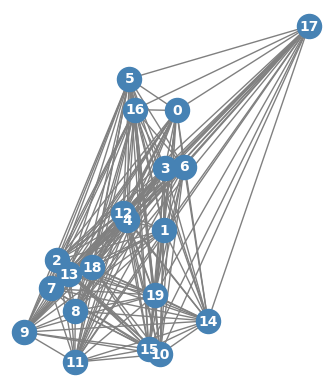

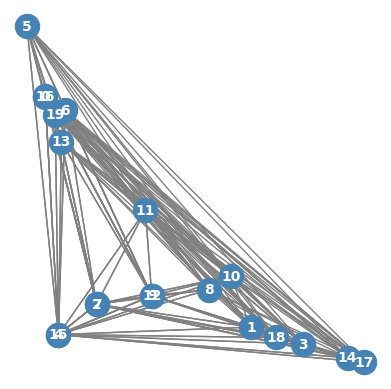

In [50]:
np.random.seed(42)
num_vertices, num_edges = 20, 45

#adjacency_list, edge_list = generate_random_adjacency_list(num_vertices, num_edges)
adjacency_list, edge_list = generate_complete_adjacency_list(num_vertices)

spring_algorithm(adjacency_list, edge_list, 0.1, 500)